In [18]:
import numpy as np
import matplotlib.pyplot as plt

from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.observables import spectral_radius

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from lib.data.map import *

In [33]:
# CELL 1 — imports + config
np.random.seed(42)

MAP = "triplet"     # "triplet" or "doubling"
T_total = 8000
x0 = np.random.rand()
noise_std = 0.0     # e.g. 0.002 later

# Train / test setup
washout = 200
T_train = 4000

# Forecast setup
sync_len = 200      # driven steps (state synchronization) right before forecast
H = 500             # closed-loop horizon used for evaluation/plot

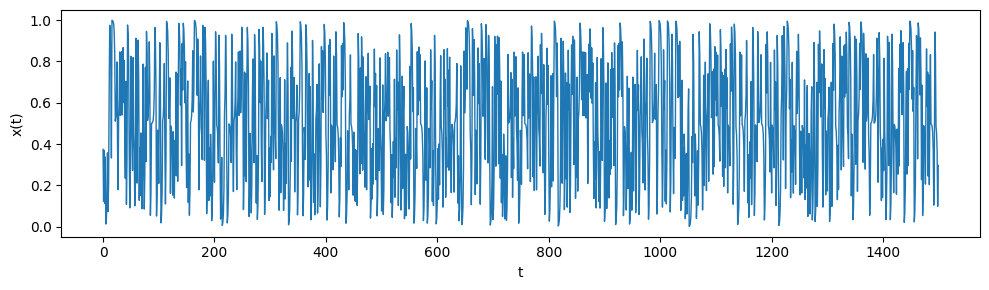

In [34]:
x = triplet_map(x0, T_total)

if noise_std > 0:
    x = add_input_noise(x, noise_std)

plt.figure(figsize=(10,3))
plt.plot(x[:1500], lw=1.0)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.tight_layout()
plt.show()

In [35]:
# CELL 3 — supervised pairs x(t)->x(t+1), split train/test
u = x[:-1].reshape(-1, 1)  # x(t)
y = x[1:].reshape(-1, 1)   # x(t+1)

train_end = washout + T_train
test_start = train_end

u_train = u[:train_end]
y_train = y[:train_end]

u_sync = u[test_start : test_start + sync_len]  # sync inputs x(t)

# We evaluate against the next H true targets x(t+1) AFTER sync
y_true_future = y[test_start + sync_len : test_start + sync_len + H, 0]

print("u_train:", u_train.shape, "y_train:", y_train.shape)
print("u_sync :", u_sync.shape)
print("y_true_future:", y_true_future.shape)

u_train: (4200, 1) y_train: (4200, 1)
u_sync : (200, 1)
y_true_future: (500,)


In [36]:
# CELL 4 — grid search optimizing CLOSED-LOOP short-horizon RMSE

# Parameter grids (keep moderate; expand later)
units_grid = [300, 600, 900]
sr_grid = [0.7, 0.9, 1.1]
lr_grid = [0.1, 0.3, 0.6]
in_scale_grid = [0.1, 0.5, 1.0]
ridge_grid = [1e-8, 1e-6, 1e-4]

# Connectivity grids (your version)
input_conn_grid = [0.05, 0.1, 0.2]
rc_conn_grid = [0.02, 0.05, 0.1]   # lower = sparser recurrent graph

best_rmse = np.inf
best_params = None
best_y_gen = None

base_seed = 123
n_eval = 0

for units in units_grid:
    for sr in sr_grid:
        for lr in lr_grid:
            for input_scaling in in_scale_grid:
                for ridge in ridge_grid:
                    for input_connectivity in input_conn_grid:
                        for rc_connectivity in rc_conn_grid:
                            n_eval += 1

                            # Build ESN (API-correct)
                            reservoir = Reservoir(
                                units=units,
                                sr=sr,
                                lr=lr,
                                input_scaling=input_scaling,
                                input_connectivity=input_connectivity,
                                rc_connectivity=rc_connectivity,
                                activation="tanh",
                                seed=base_seed,
                            )
                            readout = Ridge(ridge=ridge)
                            esn = reservoir >> readout

                            # Train (teacher-forced) with washout
                            esn = esn.fit(u_train, y_train, warmup=washout)

                            # Sync (driven by true data; no training)
                            esn.reset()
                            _ = esn.run(u_sync)

                            # Closed-loop generate H steps
                            u_curr = np.array([[float(u_sync[-1, 0])]], dtype=float)
                            y_gen = np.empty(H, dtype=float)

                            for t in range(H):
                                y_pred = esn.run(u_curr)   # predicts x(t+1)
                                y_gen[t] = y_pred[0, 0]
                                u_curr = y_pred            # feedback

                            rmse = np.sqrt(np.mean((y_gen - y_true_future) ** 2))

                            if rmse < best_rmse:
                                best_rmse = rmse
                                best_params = {
                                    "units": units,
                                    "sr": sr,
                                    "lr": lr,
                                    "input_scaling": input_scaling,
                                    "ridge": ridge,
                                    "input_connectivity": input_connectivity,
                                    "rc_connectivity": rc_connectivity,
                                    "seed": base_seed,
                                }
                                best_y_gen = y_gen.copy()

print(f"Evaluated {n_eval} configs.")
print("Best closed-loop RMSE:", best_rmse)
print("Best params:", best_params)

Evaluated 2187 configs.
Best closed-loop RMSE: 0.2851550577488399
Best params: {'units': 300, 'sr': 0.9, 'lr': 0.1, 'input_scaling': 0.1, 'ridge': 1e-08, 'input_connectivity': 0.2, 'rc_connectivity': 0.02, 'seed': 123}


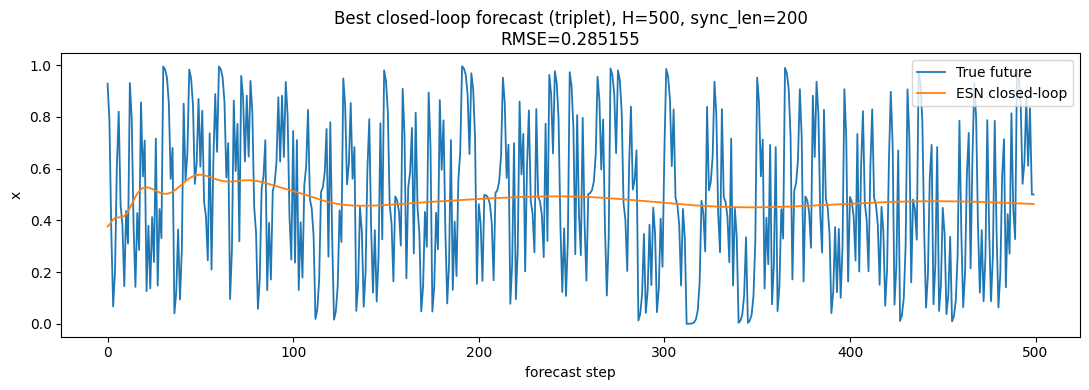

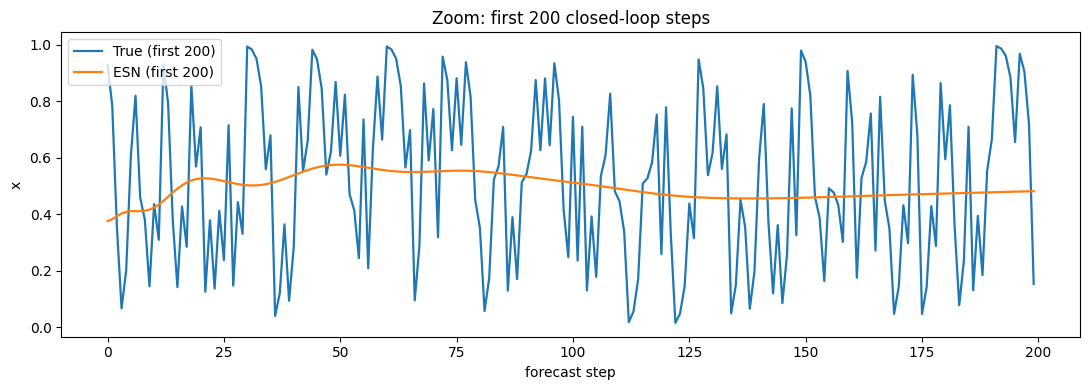

In [37]:
# CELL 5 — plot best closed-loop forecast vs true
plt.figure(figsize=(11,4))
plt.plot(y_true_future, label="True future", lw=1.3)
plt.plot(best_y_gen, label="ESN closed-loop", lw=1.3)
plt.title(f"Best closed-loop forecast ({MAP}), H={H}, sync_len={sync_len}\nRMSE={best_rmse:.6f}")
plt.xlabel("forecast step")
plt.ylabel("x")
plt.legend()
plt.tight_layout()
plt.show()

K = min(200, H)
plt.figure(figsize=(11,4))
plt.plot(y_true_future[:K], label=f"True (first {K})", lw=1.6)
plt.plot(best_y_gen[:K], label=f"ESN (first {K})", lw=1.6)
plt.title(f"Zoom: first {K} closed-loop steps")
plt.xlabel("forecast step")
plt.ylabel("x")
plt.legend()
plt.tight_layout()
plt.show()

Teacher-forced one-step RMSE on same horizon: 0.26895661016337596


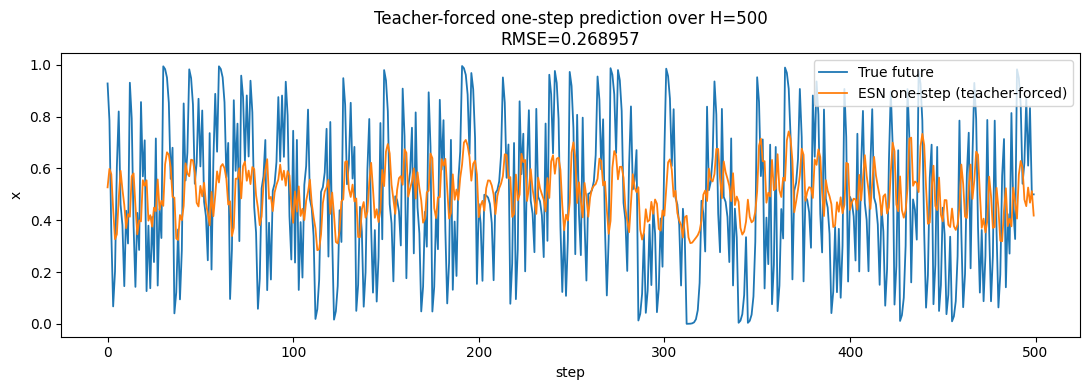

In [38]:
# CELL 6 — (optional) evaluate the best model in teacher-forced one-step mode on same window

p = best_params
reservoir = Reservoir(
    units=p["units"],
    sr=p["sr"],
    lr=p["lr"],
    input_scaling=p["input_scaling"],
    input_connectivity=p["input_connectivity"],
    rc_connectivity=p["rc_connectivity"],
    activation="tanh",
    seed=p["seed"],
)
readout = Ridge(ridge=p["ridge"])
esn = reservoir >> readout
esn = esn.fit(u_train, y_train, warmup=washout)

u_future_inputs = u[test_start + sync_len : test_start + sync_len + H]  # x(t)
y_pred_tf = esn.run(u_future_inputs)[:, 0]

rmse_tf = np.sqrt(np.mean((y_pred_tf - y_true_future) ** 2))
print("Teacher-forced one-step RMSE on same horizon:", rmse_tf)

plt.figure(figsize=(11,4))
plt.plot(y_true_future, label="True future", lw=1.3)
plt.plot(y_pred_tf, label="ESN one-step (teacher-forced)", lw=1.3)
plt.title(f"Teacher-forced one-step prediction over H={H}\nRMSE={rmse_tf:.6f}")
plt.xlabel("step")
plt.ylabel("x")
plt.legend()
plt.tight_layout()
plt.show()